In [1]:
!pip install ultralytics roboflow --quiet

import torch, ultralytics
print(f"PyTorch    : {torch.__version__}")
print(f"Ultralytics: {ultralytics.__version__}")
print(f"CUDA       : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 57.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch    : 2.10.0+cu128
Ultralytics: 8.4.39
CUDA       : True
GPU        : Tesla T4
VRAM       : 15.6 GB


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/GroceryCheckout'
MODELS_DIR  = f'{PROJECT_DIR}/models'
for d in [PROJECT_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Drive mounted. Project: {PROJECT_DIR}")

Mounted at /content/drive
Drive mounted. Project: /content/drive/MyDrive/GroceryCheckout


In [3]:
# Get your FREE key at https://app.roboflow.com → Settings → API Keys
RF_API_KEY = "7oecWxQBEEDJsxMzke60"   # ← PASTE YOUR KEY HERE

# ─── ONLY these classes will survive the merge. ───────────────────────────────
# Spelling must be lowercase with underscores.
TARGET_CLASSES = [
    "apple",
    "banana",
    "dragonfruit",
    "custard_apple",
    "diet_coke",
    "pepsi",
]

# ─── Datasets to download ─────────────────────────────────────────────────────
# If any download fails (version changed), search https://universe.roboflow.com
# for an alternative and update workspace/project/version.
DATASETS = [
    {
        "label"    : "fruits",
        "workspace": "zakirkx12",
        "project"  : "fruits-oa6gz",
        "version"  : 1,
        "dest"     : "/content/ds_fruits",
    },
    {
        "label"    : "soda",
        "workspace": "cyberwarriorstemcamp",
        "project"  : "soda-can-qr4c4",
        "version"  : 2,
        "dest"     : "/content/ds_soda",
    },
]

print("Config ready. TARGET_CLASSES:", TARGET_CLASSES)

Config ready. TARGET_CLASSES: ['apple', 'banana', 'dragonfruit', 'custard_apple', 'diet_coke', 'pepsi']


In [4]:
from roboflow import Roboflow
import yaml

rf = Roboflow(api_key=RF_API_KEY)
downloaded = {}
failed     = []

for ds in DATASETS:
    print(f"\nDownloading [{ds['label']}] ...")
    try:
        version = rf.workspace(ds["workspace"]).project(ds["project"]).version(ds["version"])
        version.download("yolov8", location=ds["dest"])

        with open(f"{ds['dest']}/data.yaml") as f:
            cfg = yaml.safe_load(f)

        downloaded[ds["label"]] = {"path": ds["dest"], "raw_cfg": cfg}
        print(f"   OK  nc={cfg['nc']}  raw names={cfg['names']}")
    except Exception as e:
        print(f"   FAILED: {e}")
        failed.append(ds["label"])

print(f"\nDownloaded : {list(downloaded.keys())}")
if failed:
    print(f"Failed : {failed}")
    print("Search https://universe.roboflow.com for alternatives.")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/ds_fruits in yolov8:: 100%|██████████| 9676/9676 [00:01<00:00, 8174.60it/s] 

   OK  nc=8  raw names=['0', '1', '2', '3', '4', '5', '6', '7']

loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to /content/ds_soda in yolov8:: 100%|██████████| 250/250 [00:00<00:00, 6118.78it/s]

   OK  nc=1  raw names=['soda-can']

Downloaded : ['fruits', 'soda']


In [5]:
# WHY THIS CELL EXISTS:
# When a dataset's data.yaml stores class names as integers (0, 1, 2 ...)
# instead of real strings, the merge produces classes named '0', '1', etc.
# This cell shows you exactly what each dataset has so you can correct it
# in MANUAL_NAME_MAP in Cell 6.

print("=" * 62)
print("RAW CLASS NAMES FROM EACH DOWNLOADED DATASET")
print("=" * 62)

for ds_label, info in downloaded.items():
    cfg   = info["raw_cfg"]
    names = cfg.get("names", [])
    print(f"\n[{ds_label}]  nc={cfg['nc']}")
    for i, n in enumerate(names):
        print(f"   class {i:>3d} : {n!r}")

print("\n" + "=" * 62)
print("ACTION:")
print("  If any class above is an integer (0, 1 ...) or a wrong name,")
print("  go to Cell 6 and fill in MANUAL_NAME_MAP before continuing.")
print("  Visit the dataset's Roboflow page to see the real class names:")
print("  https://universe.roboflow.com")
print("=" * 62)

RAW CLASS NAMES FROM EACH DOWNLOADED DATASET

[fruits]  nc=8
   class   0 : '0'
   class   1 : '1'
   class   2 : '2'
   class   3 : '3'
   class   4 : '4'
   class   5 : '5'
   class   6 : '6'
   class   7 : '7'

[soda]  nc=1
   class   0 : 'soda-can'

ACTION:
  If any class above is an integer (0, 1 ...) or a wrong name,
  go to Cell 6 and fill in MANUAL_NAME_MAP before continuing.
  Visit the dataset's Roboflow page to see the real class names:
  https://universe.roboflow.com


In [6]:
# ─── MANUAL_NAME_MAP ─────────────────────────────────────────────────────────
# After reading Cell 5's output, fill in the correct name for each class index.
# Use the dataset's Roboflow project page to look up the real label names.
#
# Format:  "dataset_label": { class_index: "target_class_name_from_TARGET_CLASSES" }
#
# Example — if 'fruits' showed class 0='0', class 1='1', and the Roboflow
# page says index 0=apple, index 1=banana, index 2=dragonfruit:
#   "fruits": { 0: "apple", 1: "banana", 2: "dragonfruit" }
#
# Classes NOT listed here (and not in SYNONYMS) are discarded.
# ─────────────────────────────────────────────────────────────────────────────

MANUAL_NAME_MAP = {
    # Fill these in after reading Cell 5. Examples shown as comments:
    "fruits": {
        0: "custard_apple",
        1: "apple",
        2: "banana",
        3: "dragonfruit",
    },
    "dragonfruit": {
        0: "dragonfruit",
    },
    "soda": {
        0: "diet_coke",
        1: "pepsi",
    },
    "grocery": {
        0: "custard_apple",
        1: "apple",
    },
}

# ─── SYNONYMS ────────────────────────────────────────────────────────────────
# Handles spelling variants automatically.
# Key = what the dataset calls it  →  Value = your TARGET_CLASSES name.
SYNONYMS = {
    # Dragonfruit variants
    "dragon_fruit"        : "dragonfruit",
    "dragon-fruit"        : "dragonfruit",
    "pitaya"              : "dragonfruit",
    "red_dragon_fruit"    : "dragonfruit",
    "white_dragon_fruit"  : "dragonfruit",

    # Custard apple variants
    "custard apple"       : "custard_apple",
    "custardapple"        : "custard_apple",
    "sugar_apple"         : "custard_apple",
    "sugar apple"         : "custard_apple",
    "sitaphal"            : "custard_apple",
    "sharifa"             : "custard_apple",
    "atemoya"             : "custard_apple",

    # Apple variants
    "red_apple"           : "apple",
    "green_apple"         : "apple",
    "fuji_apple"          : "apple",
    "fuji apple"          : "apple",
    "granny_smith"        : "apple",
    "gala_apple"          : "apple",

    # Banana variants
    "yellow_banana"       : "banana",
    "ripe_banana"         : "banana",

    # Soda variants
    "diet coke"           : "diet_coke",
    "diet-coke"           : "diet_coke",
    "coke_zero"           : "diet_coke",
    "coke zero"           : "diet_coke",
    "coca_cola_diet"      : "diet_coke",
    "coca-cola diet"      : "diet_coke",
    "pepsi_cola"          : "pepsi",
    "pepsi_max"           : "pepsi",
    "pepsi max"           : "pepsi",
    "pepsi_zero"          : "pepsi",
    "pepsi_blue"          : "pepsi",
}

print("Name corrections defined.")
print(f"TARGET_CLASSES : {TARGET_CLASSES}")
print(f"SYNONYMS       : {len(SYNONYMS)} entries")

Name corrections defined.
TARGET_CLASSES : ['apple', 'banana', 'dragonfruit', 'custard_apple', 'diet_coke', 'pepsi']
SYNONYMS       : 31 entries


In [7]:
# THE ZeroDivisionError in torch._decomp.decompositions._compute_scale comes
# from images with 0-pixel width/height (corrupt JPEGs or truncated files).
# This cell finds and deletes them along with their paired .txt label files.

from pathlib import Path
from PIL import Image as PILImage

def validate_dataset_images(root: str):
    root_path = Path(root)
    kept = removed = 0
    for img_path in root_path.rglob("*"):
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
            continue
        try:
            with PILImage.open(img_path) as img:
                w, h = img.size
                if w < 8 or h < 8:
                    raise ValueError(f"Degenerate size {w}x{h}")
                img.load()   # fully decode — catches truncated files
            kept += 1
        except Exception:
            # Remove paired label file too
            for lbl_dir in ["labels", "../labels"]:
                lbl = img_path.parent.parent / "labels" / (img_path.stem + ".txt")
                if lbl.exists():
                    lbl.unlink()
            img_path.unlink(missing_ok=True)
            removed += 1
    return kept, removed

print(f"{'Dataset':<18} {'Kept':>6} {'Removed':>8}")
print("-" * 36)
total_removed = 0
for ds_label, info in downloaded.items():
    k, r = validate_dataset_images(info["path"])
    total_removed += r
    flag = "OK" if r == 0 else f"REMOVED {r}"
    print(f"{ds_label:<18} {k:>6} {r:>8}   {flag}")

print(f"\nTotal removed: {total_removed}")
if total_removed > 0:
    print("These files were causing the ZeroDivisionError. Now safe to train.")
else:
    print("No corrupt images found. ZeroDivisionError was from multi_scale — fixed in Cell 10.")

Dataset              Kept  Removed
------------------------------------
fruits               4832        0   OK
soda                  119        0   OK

Total removed: 0
No corrupt images found. ZeroDivisionError was from multi_scale — fixed in Cell 10.


In [8]:
import shutil, yaml
from pathlib import Path
from collections import defaultdict

MERGED = Path("/content/merged_dataset")
for split in ["train", "valid", "test"]:
    (MERGED / split / "images").mkdir(parents=True, exist_ok=True)
    (MERGED / split / "labels").mkdir(parents=True, exist_ok=True)


def resolve_name(raw, ds_label, index):
    # 1. Try manual map by index
    manual = MANUAL_NAME_MAP.get(ds_label, {})
    if index in manual:
        name = str(manual[index])
    elif str(raw) in manual:
        name = str(manual[str(raw)])
    else:
        name = str(raw)

    # 2. Normalise
    name = name.lower().strip().replace(" ", "_").replace("-", "_")

    # 3. Apply synonym table (try both normalised and original)
    name = SYNONYMS.get(name, SYNONYMS.get(str(raw).lower().strip(), name))

    return name


# Build per-dataset {old_id → new_id or -1} maps
print("CLASS RESOLUTION")
print("=" * 60)
ds_class_maps = {}

for ds_label, info in downloaded.items():
    raw_names = info["raw_cfg"].get("names", [])
    mapping   = {}
    print(f"\n[{ds_label}]")
    for old_id, raw_name in enumerate(raw_names):
        resolved = resolve_name(raw_name, ds_label, old_id)
        if resolved in TARGET_CLASSES:
            new_id = TARGET_CLASSES.index(resolved)
            mapping[old_id] = new_id
            print(f"   {old_id:>3}  '{raw_name}'  ->  '{resolved}'  new_id={new_id}  KEEP")
        else:
            mapping[old_id] = -1
            print(f"   {old_id:>3}  '{raw_name}'  ->  '{resolved}'  DISCARD")
    ds_class_maps[ds_label] = mapping


# Copy + remap + filter
per_split = defaultdict(int)
per_ds    = defaultdict(lambda: {"imgs": 0, "annots": 0, "skip": 0})

for ds_label, info in downloaded.items():
    mapping  = ds_class_maps[ds_label]
    src_root = Path(info["path"])

    for split in ["train", "valid", "test"]:
        img_dir = src_root / split / "images"
        lbl_dir = src_root / split / "labels"
        if not img_dir.exists():
            continue

        for img_path in img_dir.glob("*"):
            lbl_path   = lbl_dir / (img_path.stem + ".txt")
            kept_lines = []

            if lbl_path.exists():
                with open(lbl_path) as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) < 5:
                            continue
                        new_id = mapping.get(int(parts[0]), -1)
                        if new_id >= 0:
                            kept_lines.append(f"{new_id} " + " ".join(parts[1:]))

            # Skip unannotated images (no target classes found)
            if lbl_path.exists() and not kept_lines:
                per_ds[ds_label]["skip"] += 1
                continue

            new_name = f"{ds_label}_{img_path.name}"
            shutil.copy(img_path, MERGED / split / "images" / new_name)

            dest_lbl = MERGED / split / "labels" / (Path(new_name).stem + ".txt")
            with open(dest_lbl, "w") as f:
                f.write("\n".join(kept_lines))

            per_ds[ds_label]["imgs"]   += 1
            per_ds[ds_label]["annots"] += len(kept_lines)
            per_split[split]           += 1


# Write data.yaml
DATASET_YAML = str(MERGED / "data.yaml")
with open(DATASET_YAML, "w") as f:
    yaml.dump({
        "path" : str(MERGED),
        "train": "train/images",
        "val"  : "valid/images",
        "test" : "test/images",
        "nc"   : len(TARGET_CLASSES),
        "names": TARGET_CLASSES,
    }, f, default_flow_style=False, allow_unicode=True)


# Summary
print("\n\nMERGE COMPLETE")
print("=" * 55)
print(f"{'Dataset':<18} {'Images':>7} {'Annots':>8} {'Skip':>6}")
print("-" * 55)
for ds_label, c in per_ds.items():
    print(f"{ds_label:<18} {c['imgs']:>7} {c['annots']:>8} {c['skip']:>6}")
print("-" * 55)
for split, n in per_split.items():
    print(f"  {split:<8}: {n} images")

# Verify no numeric class names
with open(DATASET_YAML) as f:
    check = yaml.safe_load(f)
bad = [n for n in check["names"] if str(n).strip().isdigit()]
if bad:
    print(f"\nWARNING: numeric class names still present: {bad}")
    print("Go back to Cell 6 → fill MANUAL_NAME_MAP → re-run Cell 8.")
else:
    print(f"\nAll {check['nc']} class names are clean: {check['names']}")

CLASS RESOLUTION

[fruits]
     0  '0'  ->  'custard_apple'  new_id=3  KEEP
     1  '1'  ->  'apple'  new_id=0  KEEP
     2  '2'  ->  'banana'  new_id=1  KEEP
     3  '3'  ->  'dragonfruit'  new_id=2  KEEP
     4  '4'  ->  '4'  DISCARD
     5  '5'  ->  '5'  DISCARD
     6  '6'  ->  '6'  DISCARD
     7  '7'  ->  '7'  DISCARD

[soda]
     0  'soda-can'  ->  'diet_coke'  new_id=4  KEEP


MERGE COMPLETE
Dataset             Images   Annots   Skip
-------------------------------------------------------
fruits                4786    14649     46
soda                   119      163      0
-------------------------------------------------------
  train   : 4266 images
  valid   : 328 images
  test    : 311 images

All 6 class names are clean: ['apple', 'banana', 'dragonfruit', 'custard_apple', 'diet_coke', 'pepsi']


Annotation counts per class (train):
---------------------------------------------
       0: apple                 2763  ███████████████████████████████████
       1: banana                5422  ███████████████████████████████████
       2: dragonfruit           1912  ███████████████████████████████████
       3: custard_apple         2683  ███████████████████████████████████
  LOW  4: diet_coke              118  ███
  LOW  5: pepsi                    0  


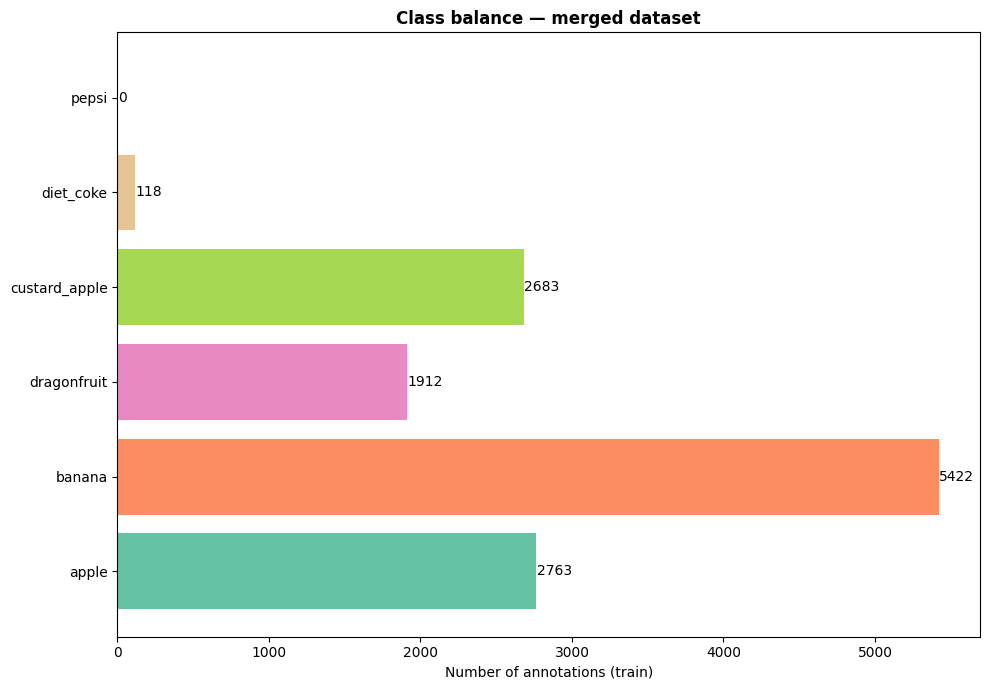


LOW DATA (< 200 annotations):
  diet_coke: 118 — find more data on universe.roboflow.com
  pepsi: 0 — find more data on universe.roboflow.com


In [9]:
import yaml
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

with open(DATASET_YAML) as f:
    cfg = yaml.safe_load(f)

class_names = cfg["names"]
nc          = cfg["nc"]

counts = defaultdict(int)
for lbl in (MERGED / "train" / "labels").glob("*.txt"):
    with open(lbl) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                counts[int(parts[0])] += 1

print("Annotation counts per class (train):")
print("-" * 45)
for i, name in enumerate(class_names):
    n    = counts.get(i, 0)
    flag = "LOW " if n < 200 else "    "
    bar  = "█" * min(n // 30, 35)
    print(f"  {flag} {i}: {name:<20} {n:>5}  {bar}")

vals   = [counts.get(i, 0) for i in range(nc)]
colors = plt.cm.Set2(np.linspace(0, 1, nc))
fig, ax = plt.subplots(figsize=(10, max(4, nc + 1)))
ax.barh(class_names, vals, color=colors)
ax.set_xlabel("Number of annotations (train)")
ax.set_title("Class balance — merged dataset", fontweight="bold")
for i, v in enumerate(vals):
    ax.text(v + 3, i, str(v), va="center")
plt.tight_layout()
plt.savefig("/content/class_balance.png", dpi=120, bbox_inches="tight")
plt.show()

low = [(class_names[i], v) for i, v in enumerate(vals) if v < 200]
if low:
    print("\nLOW DATA (< 200 annotations):")
    for name, v in low:
        print(f"  {name}: {v} — find more data on universe.roboflow.com")
else:
    print("\nAll classes have >= 200 annotations.")

In [11]:
from ultralytics import YOLO
import torch, yaml

with open(DATASET_YAML) as f:
    cfg = yaml.safe_load(f)
print(f"Training on {cfg['nc']} classes: {cfg['names']}")

BATCH, MODEL = 32, "yolov8m.pt"
print(f"Using model={MODEL}  batch={BATCH} (as requested by user)")

model = YOLO(MODEL)

results = model.train(
    data     = DATASET_YAML,
    epochs   = 55,
    imgsz    = 640,
    batch    = BATCH,
    patience = 20,
    device   = 0,
    project  = '/content/runs',
    name     = 'billbro_v3',
    exist_ok = True,

    # ── FIX 1: multi_scale=False ─────────────────────────────────────────────
    # multi_scale=True resizes images randomly during training.
    # On some batches this produced a 0-height crop -> ZeroDivisionError.
    multi_scale = False,

    # ── FIX 2: mosaic reduced from 1.0 to 0.7 ────────────────────────────────
    # Full mosaic (1.0) on small or imbalanced datasets creates edge crops
    # with 0 pixels. 0.7 gives most of the benefit safely.
    mosaic  = 0.7,
    mixup   = 0.10,

    # ── FIX 3: copy_paste=0 ───────────────────────────────────────────────────
    # copy_paste on datasets where some classes have very few examples
    # can produce annotations outside image bounds -> further errors.
    copy_paste = 0.0,

    # ── Augmentation (safe) ───────────────────────────────────────────────────
    hsv_h   = 0.02,
    hsv_s   = 0.75,
    hsv_v   = 0.45,
    fliplr  = 0.5,
    flipud  = 0.05,
    degrees = 12.0,
    scale   = 0.5,
    shear   = 4.0,
    perspective = 0.0005,

    # ── Optimiser ─────────────────────────────────────────────────────────────
    optimizer    = "AdamW",
    lr0          = 0.001,
    lrf          = 0.01,
    momentum     = 0.937,
    weight_decay = 0.0005,
    warmup_epochs= 5.0,

    # ── Regularisation ────────────────────────────────────────────────────────
    dropout         = 0.0,
    label_smoothing = 0.05,

    # ── Output ────────────────────────────────────────────────────────────────
    save        = True,
    save_period = 10,
    plots        = True,
    verbose     = True,
    amp         = True,
)

print(f"\nTraining complete!")
print(f"Best   : {results.save_dir}/weights/best.pt")
print(f"Last   : {results.save_dir}/weights/last.pt")

Training on 6 classes: ['apple', 'banana', 'dragonfruit', 'custard_apple', 'diet_coke', 'pepsi']
Using model=yolov8m.pt  batch=32 (as requested by user)
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged_dataset/data.yaml, degrees=12.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=55, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.05, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.75, hsv_v=0.45, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.

In [13]:
from ultralytics import YOLO
import numpy as np

BEST_MODEL = '/content/runs/billbro_v3/weights/best.pt'
model      = YOLO(BEST_MODEL)

metrics    = model.val(data=DATASET_YAML, imgsz=640, device=0, verbose=False)
names      = list(model.names.values())

print("╔══════════════════════════════════════════╗")
print("║       OVERALL VALIDATION METRICS         ║")
print("╠══════════════════════════════════════════╣")
print(f"║  mAP@0.5      : {metrics.box.map50:>6.3f}   (target > 0.80) ║")
print(f"║  mAP@0.5:0.95 : {metrics.box.map:>6.3f}   (target > 0.55) ║")
print(f"║  Precision    : {metrics.box.mp:>6.3f}                   ║")
print(f"║  Recall       : {metrics.box.mr:>6.3f}                   ║")
f1 = 2 * metrics.box.mp * metrics.box.mr / (metrics.box.mp + metrics.box.mr + 1e-8)
print(f"║  F1-Score     : {f1:>6.3f}                   ║")
print("╚══════════════════════════════════════════╝")

print("\n📊 Per-class AP@0.5:")
print(f"{'Class':<24} {'AP':>6}  Bar")
print("─" * 50)

ap50 = metrics.box.ap50 if hasattr(metrics.box, 'ap50') else np.zeros(len(names))
for i, name in enumerate(names):
    ap  = float(ap50[i]) if i < len(ap50) else 0.0
    bar = "█" * int(ap * 25) + "░" * (25 - int(ap * 25))
    flag = "⚠️ " if ap < 0.5 else "✅"
    print(f"{flag} {name:<22} {ap:.3f}  {bar}")

weak = [(names[i], float(ap50[i])) for i in range(len(names)) if i < len(ap50) and float(ap50[i]) < 0.5]
if weak:
    print(f"\n⚠️  Weak classes (AP < 0.5) — need more data or better labels:")
    for n, ap in sorted(weak, key=lambda x: x[1]):
        print(f"   • {n:<25} AP={ap:.3f}")

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 932.2±192.3 MB/s, size: 32.8 KB)
val: Scanning /content/merged_dataset/valid/labels.cache... 328 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 328/328 65.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 2.0it/s 10.5s
                   all        328        997      0.976      0.951       0.97      0.813
Speed: 2.7ms preprocess, 21.1ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val
╔══════════════════════════════════════════╗
║       OVERALL VALIDATION METRICS         ║
╠══════════════════════════════════════════╣
║  mAP@0.5      :  0.970   (target > 0.80) ║
║  mAP@0.5:0.95 :  0.813   (target > 0.55) ║
║  Precision    :  0.976                   ║
║

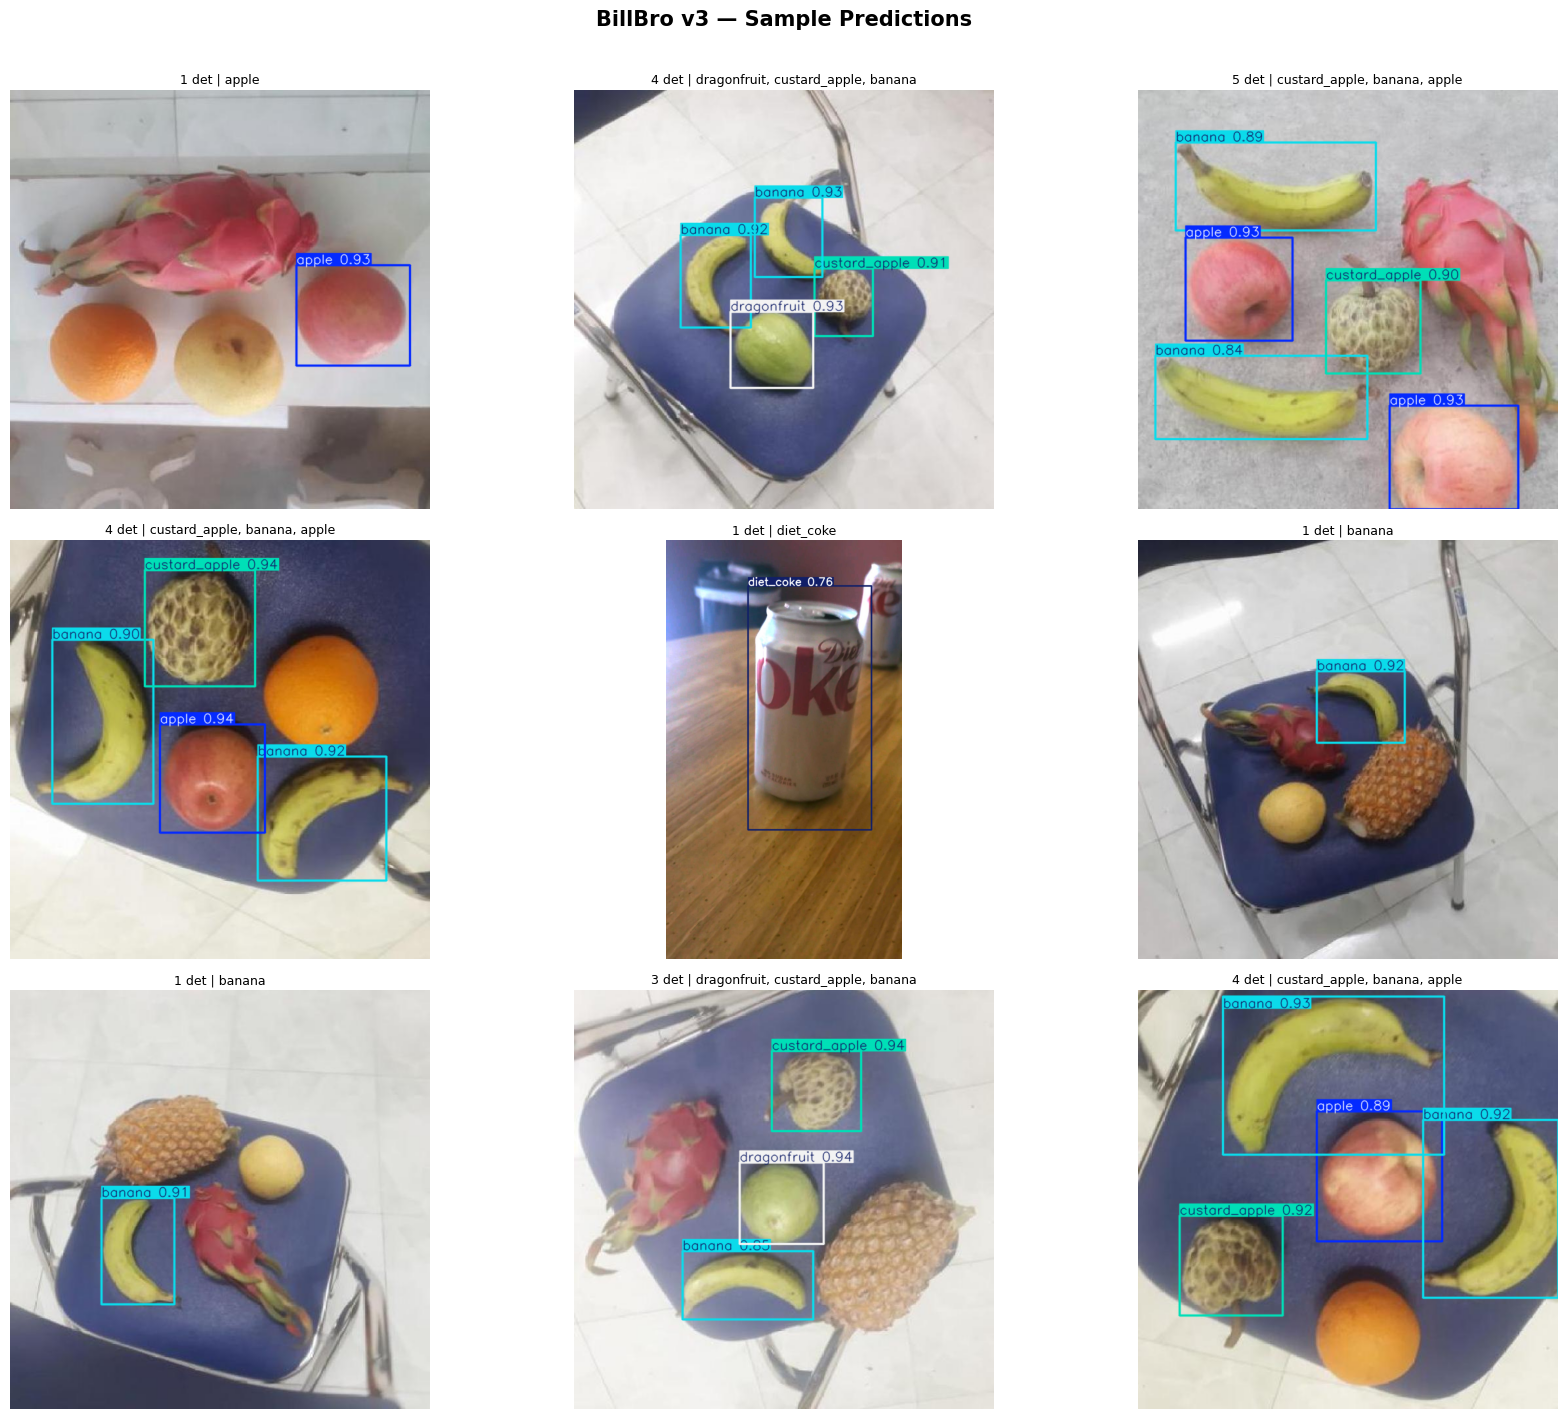

Saved → /content/sample_predictions.png


In [14]:
import glob, random
import matplotlib.pyplot as plt
from ultralytics import YOLO

model    = YOLO('/content/runs/billbro_v3/weights/best.pt')
val_imgs = glob.glob('/content/merged_dataset/valid/images/*')
sample   = random.sample(val_imgs, min(9, len(val_imgs)))

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for ax, img_path in zip(axes, sample):
    res       = model(img_path, conf=0.40, verbose=False)
    annotated = res[0].plot()
    n_det     = len(res[0].boxes)
    classes   = [model.names[int(b.cls)] for b in res[0].boxes]
    unique    = list(set(classes))

    ax.imshow(annotated[:, :, ::-1])
    ax.axis("off")
    title = f"{n_det} det | {', '.join(unique[:3])}{'...' if len(unique) > 3 else ''}"
    ax.set_title(title, fontsize=9, pad=4)

plt.suptitle("BillBro v3 — Sample Predictions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/content/sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/sample_predictions.png")

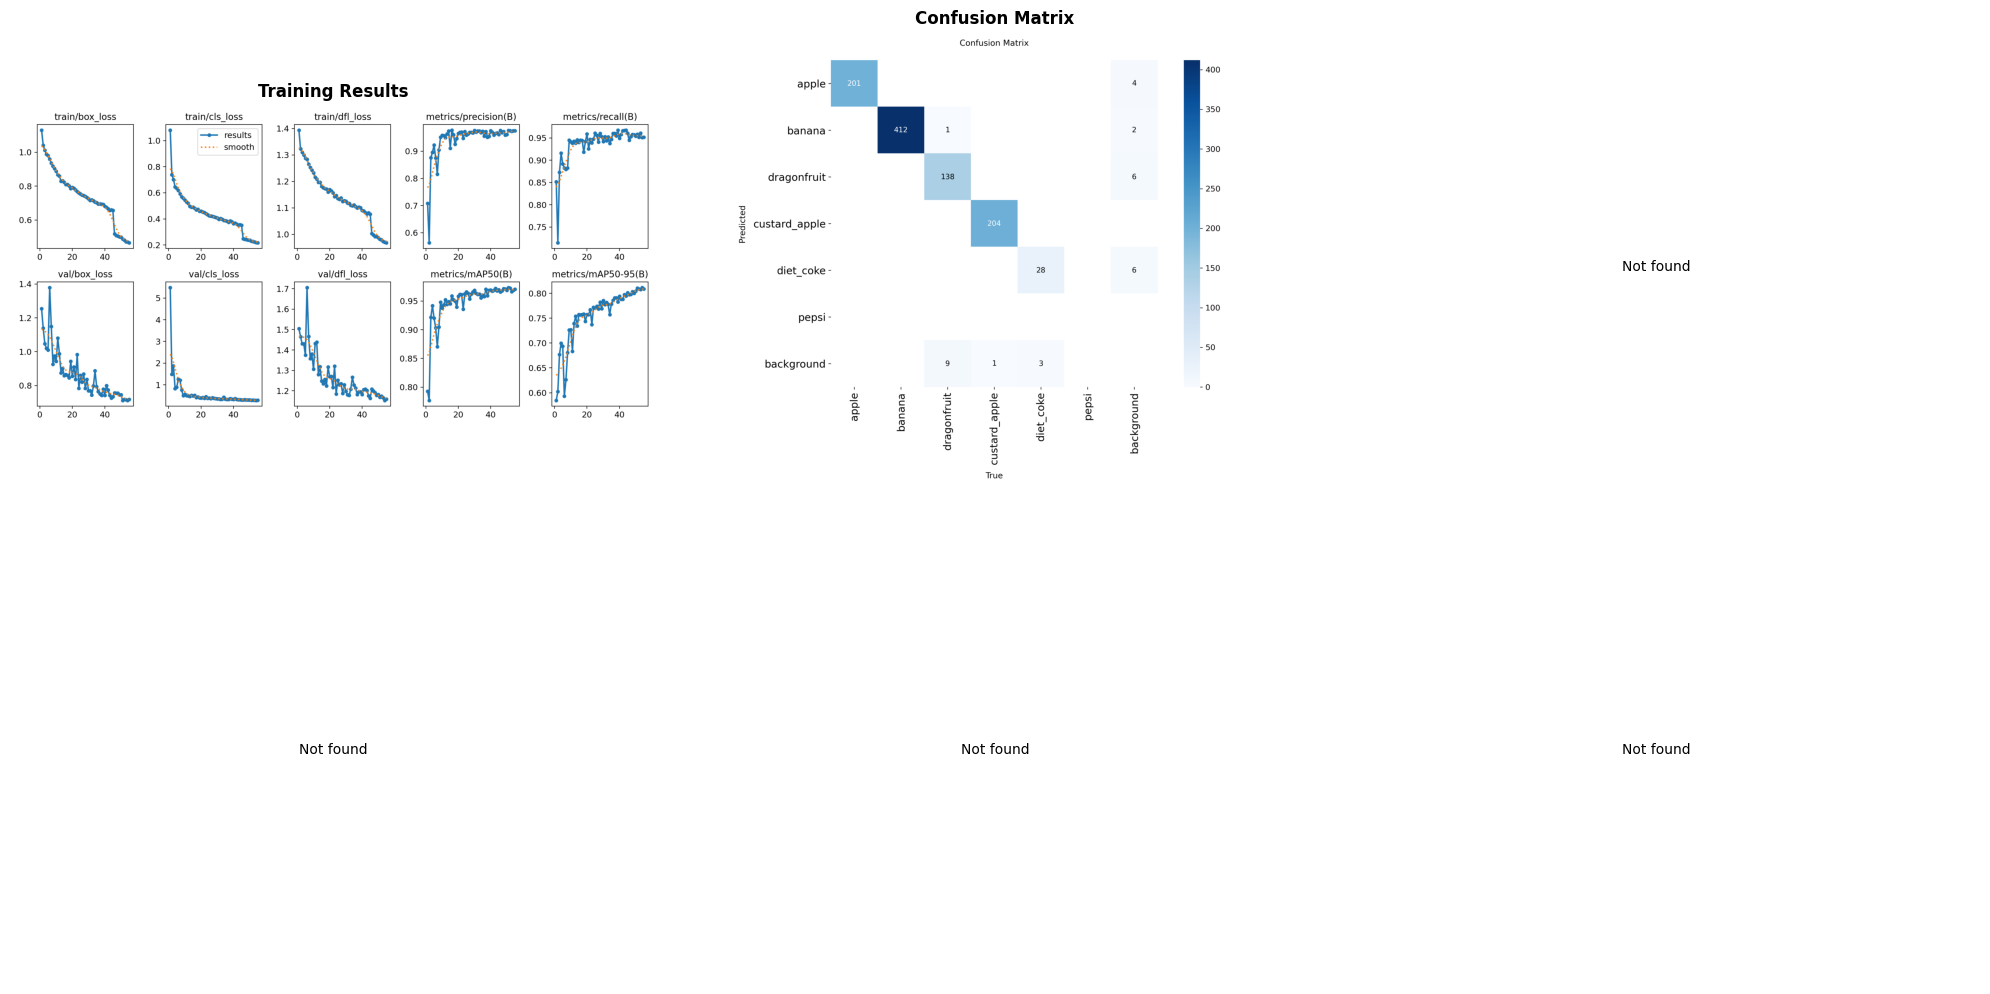

In [15]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

RUNS_DIR = '/content/runs/billbro_v3'

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
plots = [
    ("results.png",          "Training Results"),
    ("confusion_matrix.png", "Confusion Matrix"),
    ("PR_curve.png",         "PR Curve"),
    ("F1_curve.png",         "F1 Curve"),
    ("P_curve.png",          "Precision Curve"),
    ("R_curve.png",          "Recall Curve"),
]

for ax, (fname, title) in zip(axes.flatten(), plots):
    path = f"{RUNS_DIR}/{fname}"
    if os.path.exists(path):
        ax.imshow(mpimg.imread(path))
        ax.set_title(title, fontweight="bold")
    else:
        ax.text(0.5, 0.5, "Not found", ha="center", va="center")
    ax.axis("off")

plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
import shutil, os, json, yaml
from ultralytics import YOLO

# Switch to the finetune path below if you ran Cell 15
FINAL_MODEL = '/content/runs/billbro_v3/weights/best.pt'
# FINAL_MODEL = '/content/runs/billbro_v3_finetune/weights/best.pt'

model = YOLO(FINAL_MODEL)

with open(DATASET_YAML) as f:
    cfg = yaml.safe_load(f)

DRIVE_MODELS = '/content/drive/MyDrive/GroceryCheckout/models'
os.makedirs(DRIVE_MODELS, exist_ok=True)

# Save PyTorch weights
shutil.copy(FINAL_MODEL, f'{DRIVE_MODELS}/billbro_v3.pt')
print(f"✅ PyTorch model → {DRIVE_MODELS}/billbro_v3.pt")

# Export ONNX
export_path = model.export(
    format   = 'onnx',
    imgsz    = 640,
    half     = False,
    dynamic  = False,
    opset    = 17,
    simplify = True,
)
shutil.copy(str(export_path), f'{DRIVE_MODELS}/billbro_v3.onnx')
print(f"✅ ONNX model    → {DRIVE_MODELS}/billbro_v3.onnx")

# Save classes.json
classes_map = {str(i): name for i, name in enumerate(cfg["names"])}
with open(f'{DRIVE_MODELS}/classes.json', 'w') as f:
    json.dump(classes_map, f, indent=2)
print(f"✅ classes.json  → {DRIVE_MODELS}/classes.json")

# Save data.yaml
shutil.copy(DATASET_YAML, f'{DRIVE_MODELS}/data.yaml')
print(f"✅ data.yaml     → {DRIVE_MODELS}/data.yaml")

print("\n🎉 All files saved to Google Drive!")

✅ PyTorch model → /content/drive/MyDrive/GroceryCheckout/models/billbro_v3.pt
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 93 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from '/content/runs/billbro_v3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (49.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 374ms
Prepared 4 packages in 8.59s
Installed 4 packages in 482ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 10.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates

In [17]:
from google.colab import files
import os

DRIVE_MODELS = '/content/drive/MyDrive/GroceryCheckout/models'

for fname in ['billbro_v3.pt', 'billbro_v3.onnx', 'classes.json', 'data.yaml']:
    path = f'{DRIVE_MODELS}/{fname}'
    if os.path.exists(path):
        files.download(path)
        print(f"⬇  Downloading {fname}")
    else:
        print(f"❌ Not found: {fname}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  Downloading billbro_v3.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇  Downloading classes.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  Downloading data.yaml
